In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(
    r"D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\Bookings.csv"
)
#df.head()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [14]:
df.isnull().sum()

Date                               0
Time                               0
Booking_ID                         0
Booking_Status                     0
Customer_ID                        0
Vehicle_Type                       0
Pickup_Location                    0
Drop_Location                      0
V_TAT                          39057
C_TAT                          39057
Canceled_Rides_by_Customer     92525
Canceled_Rides_by_Driver       84590
Incomplete_Rides               39057
Incomplete_Rides_Reason        99098
Booking_Value                      0
Payment_Method                 39057
Ride_Distance                      0
Driver_Ratings                 39057
Customer_Rating                39057
Vehicle Images                     0
Unnamed: 20                   103024
dtype: int64

In [15]:
df[df["V_TAT"].isnull()].head()
#here we notice that the V_TAT AND C_TAT values are Null when the rides are cancelled.

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
7,2024-07-11 11:12:00,11:12:00,CNR5374902489,Canceled by Driver,CID735691,Prime Plus,Bannerghatta Road,Sarjapur Road,NaN,NaN,...,Personal & Car related issue,NaN,NaN,344,NaN,0,NaN,NaN,#NAME?,NaN
8,2024-07-01 19:19:00,19:19:00,CNR5030602354,Driver Not Found,CID999840,Mini,Chamarajpet,Peenya,NaN,NaN,...,NaN,NaN,NaN,839,NaN,0,NaN,NaN,#NAME?,NaN
9,2024-07-18 1:31:00,01:31:00,CNR6328453219,Canceled by Driver,CID907133,Auto,RT Nagar,Varthur,NaN,NaN,...,Personal & Car related issue,NaN,NaN,893,NaN,0,NaN,NaN,#NAME?,NaN


Filling the Null values using fillna and filling according to the data present in each column

In [16]:
df.drop(columns=['Unnamed: 20'],inplace=True)

df["V_TAT"] = df["V_TAT"].fillna(0)
df["C_TAT"] = df["C_TAT"].fillna(0)
df["Driver_Ratings"] = df["Driver_Ratings"].fillna(0)
df["Customer_Rating"] = df["Customer_Rating"].fillna(0)

df["Payment_Method"] = df["Payment_Method"].fillna("Not Applicable")
df["Canceled_Rides_by_Customer"] = df["Canceled_Rides_by_Customer"].fillna("No Cancellation")
df["Canceled_Rides_by_Driver"] = df["Canceled_Rides_by_Driver"].fillna("No Cancellation")
df["Incomplete_Rides"] = df["Incomplete_Rides"].fillna("Completed")
df["Incomplete_Rides_Reason"] = df["Incomplete_Rides_Reason"].fillna("Not Applicable")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       103024 non-null  float64
 9   C_TAT                       103024 non-null  float64
 10  Canceled_Rides_by_Customer  103024 non-null  object 
 11  Canceled_Rides_by_Driver    103024 non-null  object 
 12  Incomplete_Rides            103024 non-null  object 
 13  Incomplete_Rid

In [17]:
df.head(10)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,0.0,0.0,No Cancellation,Personal & Car related issue,Completed,Not Applicable,444,Not Applicable,0,0.0,0.0,#NAME?
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,No Cancellation,No Cancellation,No,Not Applicable,158,Cash,13,4.1,4.0,#NAME?
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,No Cancellation,No Cancellation,No,Not Applicable,386,UPI,40,4.2,4.8,#NAME?
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,0.0,0.0,Driver is not moving towards pickup location,No Cancellation,Completed,Not Applicable,384,Not Applicable,0,0.0,0.0,#NAME?
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,No Cancellation,No Cancellation,No,Not Applicable,822,Credit Card,45,4.0,3.0,#NAME?
5,2024-07-13 4:42:00,04:42:00,CNR8787177882,Success,CID802429,Mini,Kadugodi,Vijayanagar,231.0,90.0,No Cancellation,No Cancellation,No,Not Applicable,173,UPI,41,3.4,4.6,#NAME?
6,2024-07-23 9:51:00,09:51:00,CNR3612067560,Success,CID476071,Bike,Tumkur Road,Whitefield,133.0,40.0,No Cancellation,No Cancellation,No,Not Applicable,140,Cash,49,3.2,4.5,#NAME?
7,2024-07-11 11:12:00,11:12:00,CNR5374902489,Canceled by Driver,CID735691,Prime Plus,Bannerghatta Road,Sarjapur Road,0.0,0.0,No Cancellation,Personal & Car related issue,Completed,Not Applicable,344,Not Applicable,0,0.0,0.0,#NAME?
8,2024-07-01 19:19:00,19:19:00,CNR5030602354,Driver Not Found,CID999840,Mini,Chamarajpet,Peenya,0.0,0.0,No Cancellation,No Cancellation,Completed,Not Applicable,839,Not Applicable,0,0.0,0.0,#NAME?
9,2024-07-18 1:31:00,01:31:00,CNR6328453219,Canceled by Driver,CID907133,Auto,RT Nagar,Varthur,0.0,0.0,No Cancellation,Personal & Car related issue,Completed,Not Applicable,893,Not Applicable,0,0.0,0.0,#NAME?


In [18]:
df["Time"]=pd.to_datetime(df['Time'],format='%H:%M:%S')
df["Date"]=pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  datetime64[ns]
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       103024 non-null  float64       
 9   C_TAT                       103024 non-null  float64       
 10  Canceled_Rides_by_Customer  103024 non-null  object        
 11  Canceled_Rides_by_Driver    103024 non-

In [19]:
df['Hour']=df['Time'].dt.hour
df['Day'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.dayofweek
df.head(10)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Hour,Day,Month,Weekday
0,2024-07-26 14:00:00,1900-01-01 14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,0.0,0.0,...,444,Not Applicable,0,0.0,0.0,#NAME?,14,Friday,July,4
1,2024-07-25 22:20:00,1900-01-01 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,158,Cash,13,4.1,4.0,#NAME?,22,Thursday,July,3
2,2024-07-30 19:59:00,1900-01-01 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,386,UPI,40,4.2,4.8,#NAME?,19,Tuesday,July,1
3,2024-07-22 03:15:00,1900-01-01 03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,0.0,0.0,...,384,Not Applicable,0,0.0,0.0,#NAME?,3,Monday,July,0
4,2024-07-02 09:02:00,1900-01-01 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,822,Credit Card,45,4.0,3.0,#NAME?,9,Tuesday,July,1
5,2024-07-13 04:42:00,1900-01-01 04:42:00,CNR8787177882,Success,CID802429,Mini,Kadugodi,Vijayanagar,231.0,90.0,...,173,UPI,41,3.4,4.6,#NAME?,4,Saturday,July,5
6,2024-07-23 09:51:00,1900-01-01 09:51:00,CNR3612067560,Success,CID476071,Bike,Tumkur Road,Whitefield,133.0,40.0,...,140,Cash,49,3.2,4.5,#NAME?,9,Tuesday,July,1
7,2024-07-11 11:12:00,1900-01-01 11:12:00,CNR5374902489,Canceled by Driver,CID735691,Prime Plus,Bannerghatta Road,Sarjapur Road,0.0,0.0,...,344,Not Applicable,0,0.0,0.0,#NAME?,11,Thursday,July,3
8,2024-07-01 19:19:00,1900-01-01 19:19:00,CNR5030602354,Driver Not Found,CID999840,Mini,Chamarajpet,Peenya,0.0,0.0,...,839,Not Applicable,0,0.0,0.0,#NAME?,19,Monday,July,0
9,2024-07-18 01:31:00,1900-01-01 01:31:00,CNR6328453219,Canceled by Driver,CID907133,Auto,RT Nagar,Varthur,0.0,0.0,...,893,Not Applicable,0,0.0,0.0,#NAME?,1,Thursday,July,3


In [20]:
df.describe()

,Date,Time,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Hour,Weekday
count,103024,103024,103024.000000,103024.000000,103024.000000,103024.000000,103024.000000,103024.000000,103024.000000,103024.000000
mean,2024-07-16 11:31:38.879678720,1900-01-01 11:58:37.453991424,106.096502,52.697381,548.751883,14.189927,2.481997,2.482529,11.485528,2.792213
min,2024-07-01 00:00:00,1900-01-01 00:00:00,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-07-08 18:41:00,1900-01-01 06:01:00,0.000000,0.000000,242.000000,0.000000,0.000000,0.000000,6.000000,1.000000
50%,2024-07-16 11:23:00,1900-01-01 11:58:00,84.000000,45.000000,386.000000,8.000000,3.400000,3.400000,11.000000,3.000000
75%,2024-07-24 05:18:00,1900-01-01 17:57:00,196.000000,95.000000,621.000000,26.000000,4.200000,4.200000,17.000000,5.000000
max,2024-07-31 23:58:00,1900-01-01 23:59:00,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,23.000000,6.000000
std,NaN,NaN,104.532203,50.005090,536.541221,15.776270,1.991983,1.992770,6.912131,2.004811


In [21]:
#How many total bookings were made?
print(df["Booking_ID"].count())

103024


In [22]:
#How many bookings fall under each Booking Status
booking_status_cat=df.groupby("Booking_Status")["Booking_ID"].count().reset_index(0)
booking_status_cat

,Booking_Status,Booking_ID
0,Canceled by Customer,10499
1,Canceled by Driver,18434
2,Driver Not Found,10124
3,Success,63967


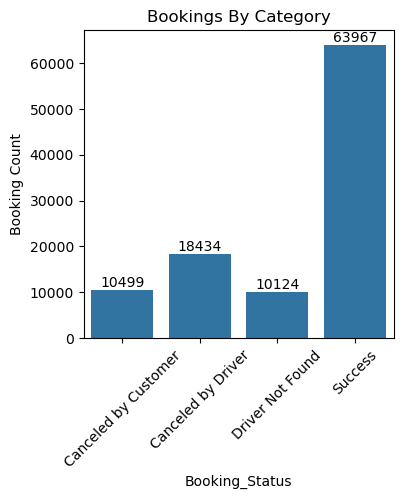

In [23]:
#PLotting the above data
plt.figure(figsize=(4,4))
ax=sns.barplot(booking_status_cat,x='Booking_Status',y='Booking_ID')
ax.bar_label(ax.containers[0])
plt.xlabel("Booking_Status")
plt.ylabel("Booking Count")
plt.xticks(rotation=45)
plt.title("Bookings By Category")
plt.show()

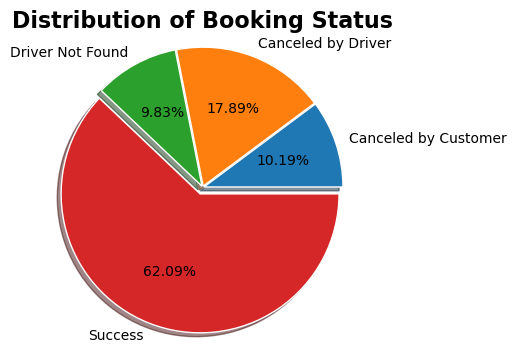

In [24]:
#What percentage of bookings were Successful,Cancelled,Incomplete
plt.figure(figsize=(4,4))
plt.pie(booking_status_cat['Booking_ID'],
        labels=booking_status_cat['Booking_Status'],
        autopct='%1.2f%%',
        wedgeprops={'edgecolor':'white'},
        explode=[0.01,0.01,0.01,0.05],
        shadow=True)
plt.title("Distribution of Booking Status", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

In [25]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Hour', 'Day', 'Month', 'Weekday'],
      dtype='object')

In [26]:
#Which vehicle type is booked the most?
vehicle_booking=df.groupby("Vehicle_Type")['Booking_ID'].count().reset_index(0)
vehicle_booking

,Vehicle_Type,Booking_ID
0,Auto,14755
1,Bike,14662
2,Mini,14552
3,Prime Plus,14707
4,Prime SUV,14655
5,Prime Sedan,14877
6,eBike,14816


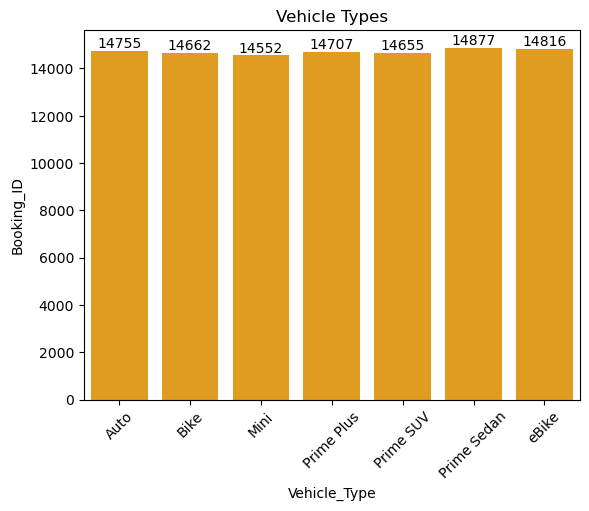

In [27]:
ax=sns.barplot(vehicle_booking,x='Vehicle_Type',y="Booking_ID",color='orange')
ax.bar_label(ax.containers[0])
plt.title("Vehicle Types")
plt.xticks(rotation=45)
plt.show()

In [28]:
#Which vehicle type generated the highest booking value?
vehicle_fare_value=df.groupby('Vehicle_Type')['Booking_Value'].sum().reset_index(0)
vehicle_fare_value=vehicle_fare_value.sort_values(by='Booking_Value',ascending=False)
vehicle_fare_value

,Vehicle_Type,Booking_Value
5,Prime Sedan,8298612
6,eBike,8181523
0,Auto,8092210
3,Prime Plus,8050889
2,Mini,7990996
1,Bike,7987054
4,Prime SUV,7933330


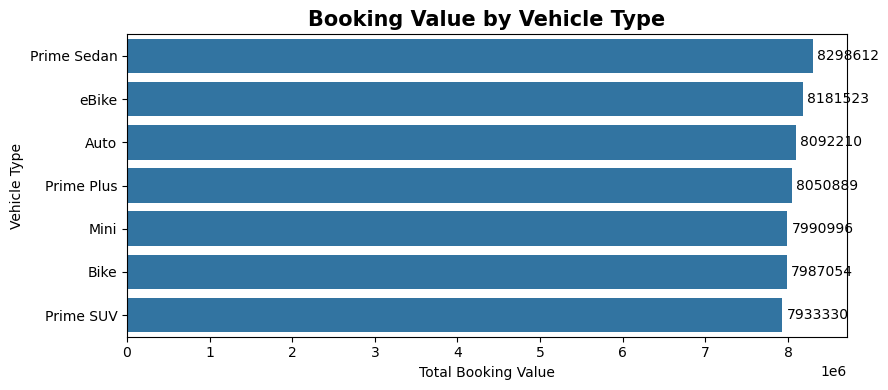

In [29]:
plt.figure(figsize=(9,4))

ax = sns.barplot(
    data=vehicle_fare_value,
    y='Vehicle_Type',
    x='Booking_Value'
)

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.title("Booking Value by Vehicle Type", fontsize=15, fontweight='bold')
plt.xlabel("Total Booking Value")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

In [30]:
#Calculate the average booking value for every vehicle type.
avg_booking_vehicle=df.groupby("Vehicle_Type")["Booking_Value"].mean().reset_index(0)
avg_booking_vehicle=avg_booking_vehicle.sort_values(by='Booking_Value',ascending=False)
avg_booking_vehicle

,Vehicle_Type,Booking_Value
5,Prime Sedan,557.814882
6,eBike,552.208626
2,Mini,549.133865
0,Auto,548.438495
3,Prime Plus,547.418848
1,Bike,544.745192
4,Prime SUV,541.339475


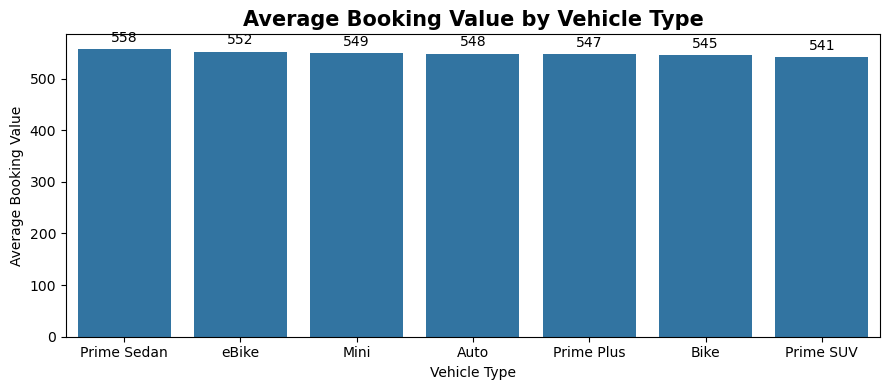

In [31]:
plt.figure(figsize=(9,4))

ax = sns.barplot(
    data=avg_booking_vehicle,
    x='Vehicle_Type',
    y='Booking_Value'
)

ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
plt.title("Average Booking Value by Vehicle Type", fontsize=15, fontweight='bold')
plt.ylabel("Average Booking Value")
plt.xlabel("Vehicle Type")

plt.tight_layout()
plt.show()

In [32]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Hour,Day,Month,Weekday
0,2024-07-26 14:00:00,1900-01-01 14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,0.0,0.0,...,444,Not Applicable,0,0.0,0.0,#NAME?,14,Friday,July,4
1,2024-07-25 22:20:00,1900-01-01 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,158,Cash,13,4.1,4.0,#NAME?,22,Thursday,July,3
2,2024-07-30 19:59:00,1900-01-01 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,386,UPI,40,4.2,4.8,#NAME?,19,Tuesday,July,1
3,2024-07-22 03:15:00,1900-01-01 03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,0.0,0.0,...,384,Not Applicable,0,0.0,0.0,#NAME?,3,Monday,July,0
4,2024-07-02 09:02:00,1900-01-01 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,822,Credit Card,45,4.0,3.0,#NAME?,9,Tuesday,July,1


In [33]:
#Which payment method is used the most?
most_payment_method= df[df["Payment_Method"] != "Not Applicable"].groupby("Payment_Method")["Booking_ID"].count().reset_index(0)
most_payment_method=most_payment_method.sort_values(by='Booking_ID',ascending=False)
#most_payment_method=df[(df["Booking_Status"]=="Success") & (df["Payment_Method" !="Not Applicable"])]
most_payment_method

,Payment_Method,Booking_ID
0,Cash,35022
3,UPI,25881
1,Credit Card,2435
2,Debit Card,629


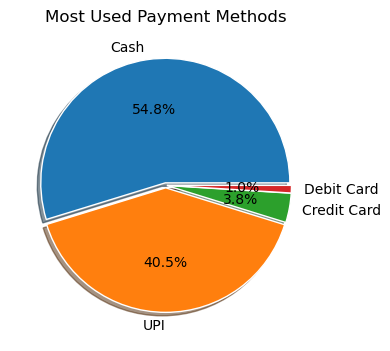

In [34]:
plt.figure(figsize=(4,4))
plt.pie(most_payment_method['Booking_ID'],
        labels=most_payment_method["Payment_Method"],
        autopct="%1.1f%%",
        wedgeprops={"edgecolor":"white"},
        shadow=True,
        explode=[0.02,0.02,0.01,0.01])
plt.title("Most Used Payment Methods")
plt.tight_layout()
plt.show()

In [35]:
#Top 10 pickup locations based on bookings
top_pickup_loc=df.groupby("Pickup_Location")["Booking_ID"].count().reset_index(0)
top_pickup_loc=top_pickup_loc.sort_values(by="Booking_ID",ascending=False)
top_pickup_loc.head(10)

,Pickup_Location,Booking_ID
1,Banashankari,2201
49,Yeshwanthpur,2139
34,RT Nagar,2135
16,Indiranagar,2133
39,Sahakar Nagar,2126
3,Basavanagudi,2120
37,Ramamurthy Nagar,2116
46,Vijayanagar,2113
43,Tumkur Road,2105
7,Cox Town,2100


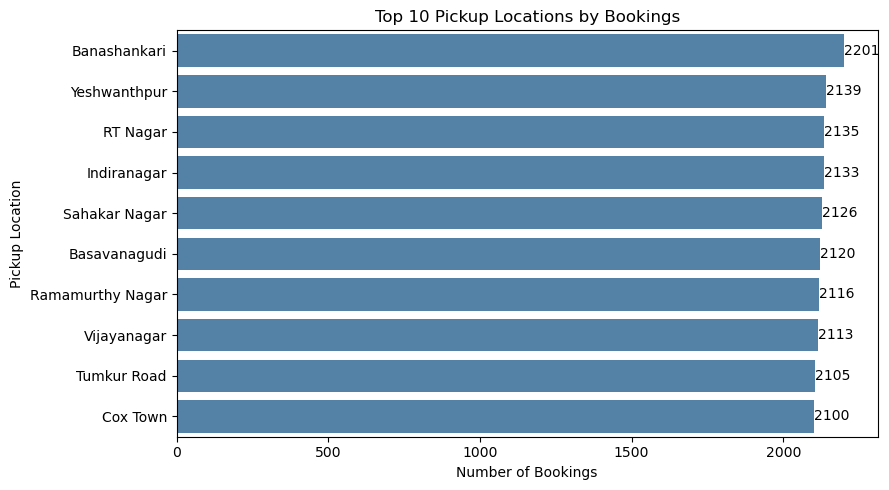

In [36]:
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=top_pickup_loc.head(10),
    y="Pickup_Location",
    x="Booking_ID",
    color="steelblue"
)
ax.bar_label(ax.containers[0])
plt.title("Top 10 Pickup Locations by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Pickup Location")
plt.tight_layout()
plt.show()

In [37]:
#Top 10 drop locations based on bookings
top_drop_loc=df.groupby("Drop_Location")["Booking_ID"].count().reset_index(0)
top_drop_loc=top_drop_loc.sort_values(by="Booking_ID",ascending=False)
top_drop_loc.head(10)

,Drop_Location,Booking_ID
33,Peenya,2159
30,Mysore Road,2148
25,MG Road,2128
13,Hennur,2120
11,HSR Layout,2117
40,Sarjapur Road,2108
23,Koramangala,2105
29,Marathahalli,2104
46,Vijayanagar,2103
12,Hebbal,2097


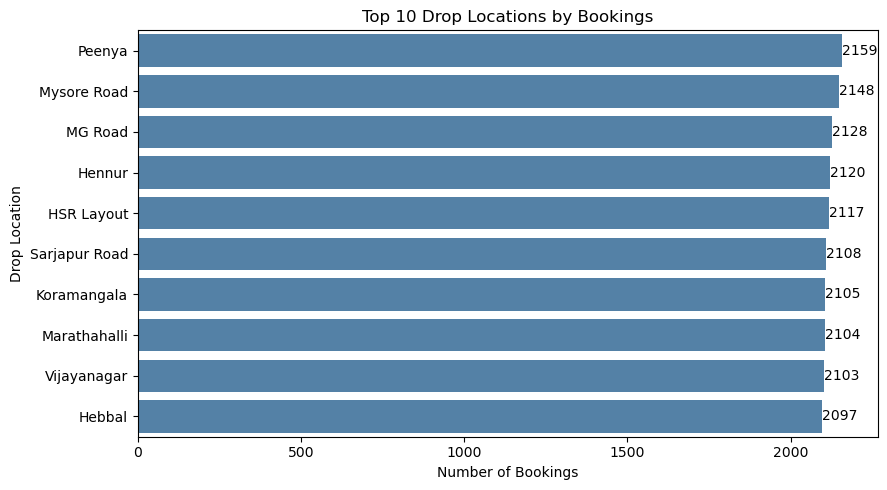

In [38]:
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=top_drop_loc.head(10),
    y="Drop_Location",
    x="Booking_ID",
    color="steelblue"
)
ax.bar_label(ax.containers[0])
plt.title("Top 10 Drop Locations by Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Drop Location")
plt.tight_layout()
plt.show()

In [39]:
#Q12. Which Pickup–Drop route is the most common?
df["Pick_Drop_Location"]=df['Pickup_Location']+"-"+df["Drop_Location"]
df["Pick_Drop_Location"].head(10)

0               Tumkur Road-RT Nagar
1                Magadi Road-Varthur
2              Sahakar Nagar-Varthur
3             HSR Layout-Vijayanagar
4            Rajajinagar-Chamarajpet
5               Kadugodi-Vijayanagar
6             Tumkur Road-Whitefield
7    Bannerghatta Road-Sarjapur Road
8                 Chamarajpet-Peenya
9                   RT Nagar-Varthur
Name: Pick_Drop_Location, dtype: object

In [40]:
pick_drop=(df.groupby("Pick_Drop_Location")["Booking_ID"].count().sort_values(ascending=False).reset_index(0).head(10))
pick_drop

,Pick_Drop_Location,Booking_ID
0,Majestic-Hennur,67
1,Ramamurthy Nagar-Frazer Town,62
2,Sahakar Nagar-Yeshwanthpur,62
3,Kammanahalli-Kadugodi,61
4,Magadi Road-Vijayanagar,60
5,Nagarbhavi-Nagarbhavi,60
6,Bellandur-Indiranagar,60
7,Hulimavu-Banashankari,60
8,KR Puram-Electronic City,59
9,Yelahanka-Frazer Town,59


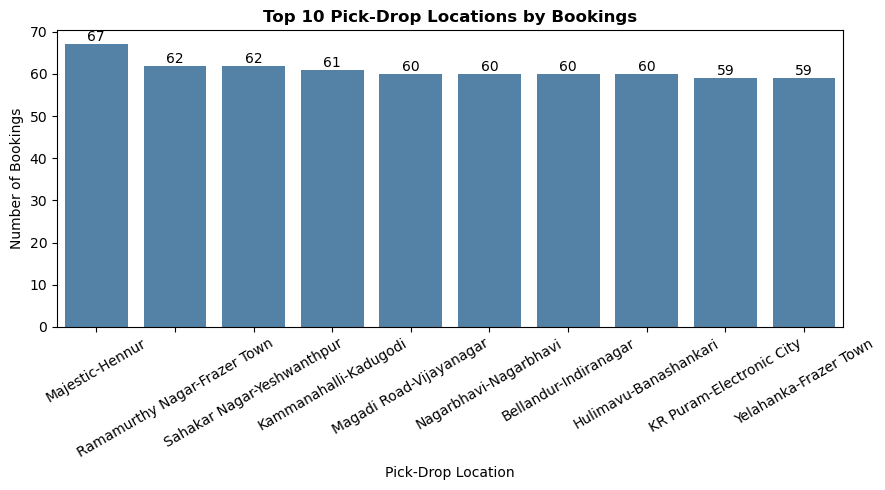

In [41]:
plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=pick_drop,
    x="Pick_Drop_Location",
    y="Booking_ID",
    color="steelblue"
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30)
plt.title("Top 10 Pick-Drop Locations by Bookings",weight='bold')
plt.ylabel("Number of Bookings")
plt.xlabel("Pick-Drop Location")
plt.tight_layout()
plt.show()

In [42]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Hour', 'Day', 'Month', 'Weekday',
       'Pick_Drop_Location'],
      dtype='object')

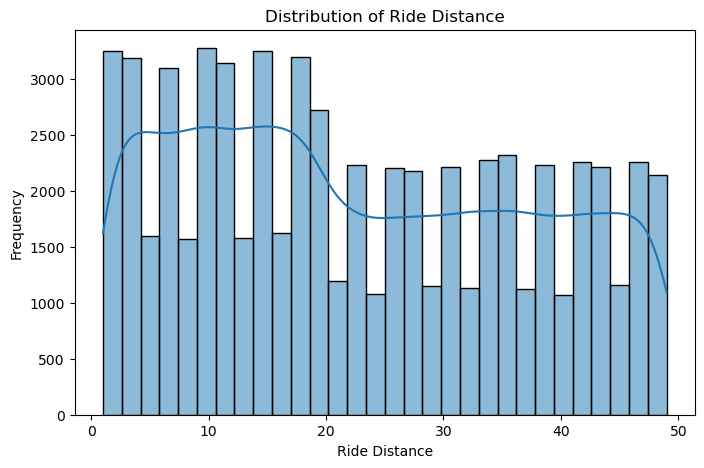

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df[df["Ride_Distance"]>0],
    x="Ride_Distance",
    bins=30,
    kde=True
)
plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance")
plt.ylabel("Frequency")

plt.show()

In [44]:
#Customer Rating Distribution
customer_rating_dist=(df[df["Customer_Rating"]>0].groupby("Customer_Rating")["Booking_ID"].count().sort_values(ascending=False).reset_index(0))
customer_rating_dist

,Customer_Rating,Booking_ID
0,4.9,3289
1,3.9,3286
2,3.5,3275
3,3.7,3264
4,4.0,3259
5,3.2,3222
6,4.8,3216
7,3.4,3210
8,4.4,3210
9,3.3,3194


<function matplotlib.pyplot.show(close=None, block=None)>

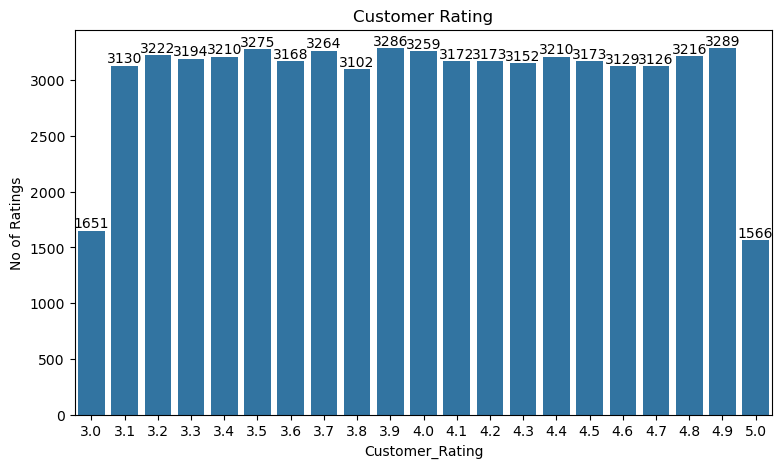

In [45]:
plt.figure(figsize=(9,5))
ax=sns.barplot(customer_rating_dist,x="Customer_Rating",y="Booking_ID")
plt.ylabel('No of Ratings')
ax.bar_label(ax.containers[0])
plt.title("Customer Rating")
plt.show

In [46]:
#Driver Rating Distribution
driver_rating_dist=(df[df["Driver_Ratings"]>0].groupby("Driver_Ratings")["Booking_ID"].count().sort_values(ascending=False).reset_index(0))
driver_rating_dist

,Driver_Ratings,Booking_ID
0,3.8,3313
1,3.9,3274
2,3.1,3273
3,4.2,3259
4,3.3,3249
5,3.5,3235
6,4.7,3232
7,4.1,3231
8,4.5,3214
9,3.7,3208


<function matplotlib.pyplot.show(close=None, block=None)>

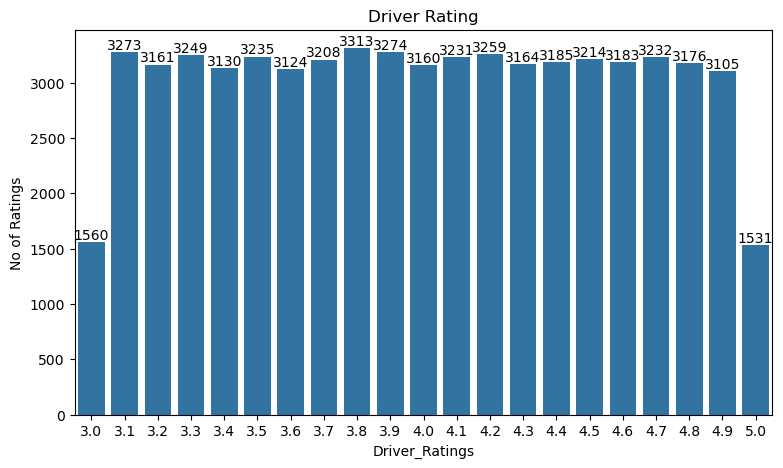

In [47]:
plt.figure(figsize=(9,5))
ax=sns.barplot(driver_rating_dist,x="Driver_Ratings",y="Booking_ID")
plt.ylabel('No of Ratings')
ax.bar_label(ax.containers[0])
plt.title("Driver Rating")
plt.show

In [48]:
#Compare Avg Driver Rating vs Customer Rating in Vehicle Type
rating_df = df[
    (df["Driver_Ratings"] > 0) &
    (df["Customer_Rating"] > 0)
]
rating_df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Hour,Day,Month,Weekday,Pick_Drop_Location
1,2024-07-25 22:20:00,1900-01-01 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,Cash,13,4.1,4.0,#NAME?,22,Thursday,July,3,Magadi Road-Varthur
2,2024-07-30 19:59:00,1900-01-01 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,UPI,40,4.2,4.8,#NAME?,19,Tuesday,July,1,Sahakar Nagar-Varthur
4,2024-07-02 09:02:00,1900-01-01 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,Credit Card,45,4.0,3.0,#NAME?,9,Tuesday,July,1,Rajajinagar-Chamarajpet
5,2024-07-13 04:42:00,1900-01-01 04:42:00,CNR8787177882,Success,CID802429,Mini,Kadugodi,Vijayanagar,231.0,90.0,...,UPI,41,3.4,4.6,#NAME?,4,Saturday,July,5,Kadugodi-Vijayanagar
6,2024-07-23 09:51:00,1900-01-01 09:51:00,CNR3612067560,Success,CID476071,Bike,Tumkur Road,Whitefield,133.0,40.0,...,Cash,49,3.2,4.5,#NAME?,9,Tuesday,July,1,Tumkur Road-Whitefield


In [49]:
avg_rating = (
    rating_df
    .groupby("Vehicle_Type")[["Driver_Ratings", "Customer_Rating"]]
    .mean()
    .reset_index()
)
avg_rating

,Vehicle_Type,Driver_Ratings,Customer_Rating
0,Auto,4.003938,3.998811
1,Bike,3.984651,3.993376
2,Mini,3.992807,3.997731
3,Prime Plus,3.997785,4.009499
4,Prime SUV,4.005780,3.999378
5,Prime Sedan,3.990681,4.001589
6,eBike,4.006743,3.987854


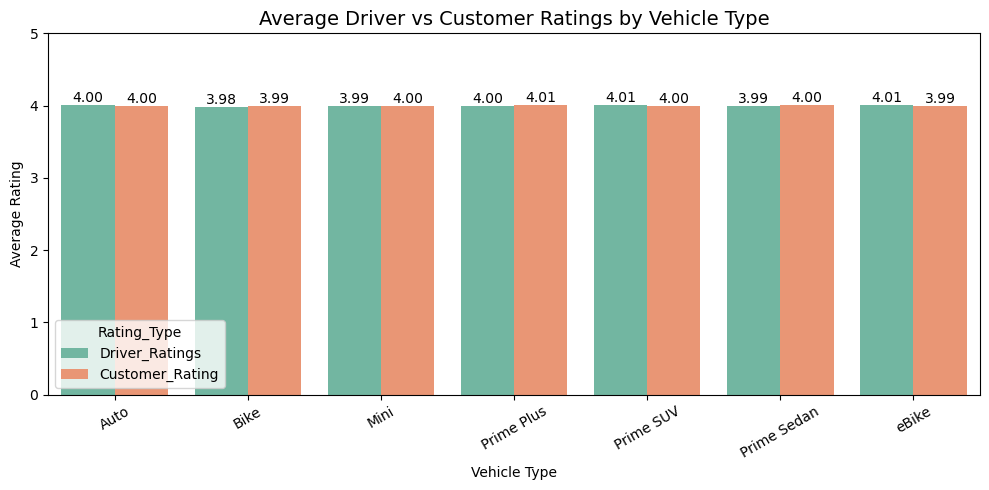

In [50]:
plt.figure(figsize=(10,5))
rating_long = avg_rating.melt(
    id_vars="Vehicle_Type",
    value_vars=["Driver_Ratings", "Customer_Rating"],
    var_name="Rating_Type",
    value_name="Average_Rating"
)
ax = sns.barplot(
    data=rating_long,
    x="Vehicle_Type",
    y="Average_Rating",
    hue="Rating_Type",
    palette="Set2"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.title("Average Driver vs Customer Ratings by Vehicle Type", fontsize=14)
plt.xlabel("Vehicle Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=30)
plt.ylim(0,5)
plt.tight_layout()
plt.show()

In [51]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Hour', 'Day', 'Month', 'Weekday',
       'Pick_Drop_Location'],
      dtype='object')

In [52]:
customer_cancel= (df[df["Canceled_Rides_by_Customer"]!='No Cancellation'].groupby('Canceled_Rides_by_Customer')["Booking_ID"]
                  .count().sort_values(ascending=False)
                  .reset_index(0))
customer_cancel

,Canceled_Rides_by_Customer,Booking_ID
0,Driver is not moving towards pickup location,3175
1,Driver asked to cancel,2670
2,Change of plans,2081
3,AC is Not working,1568
4,Wrong Address,1005


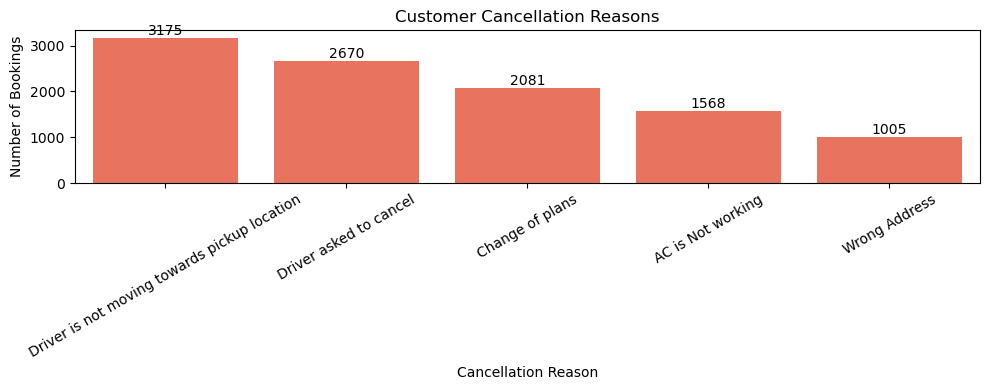

In [53]:
plt.figure(figsize=(10,4))
ax = sns.barplot(
    data=customer_cancel,
    x="Canceled_Rides_by_Customer",
    y="Booking_ID",
    color="tomato"
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30)
plt.title("Customer Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

In [54]:
#Top Driver Cancellation Reasons
driver_cancel= (df[df["Canceled_Rides_by_Driver"]!='No Cancellation'].groupby('Canceled_Rides_by_Driver')["Booking_ID"]
                  .count().sort_values(ascending=False)
                  .reset_index(0))
driver_cancel

,Canceled_Rides_by_Driver,Booking_ID
0,Personal & Car related issue,6542
1,Customer related issue,5413
2,Customer was coughing/sick,3654
3,More than permitted people in there,2825


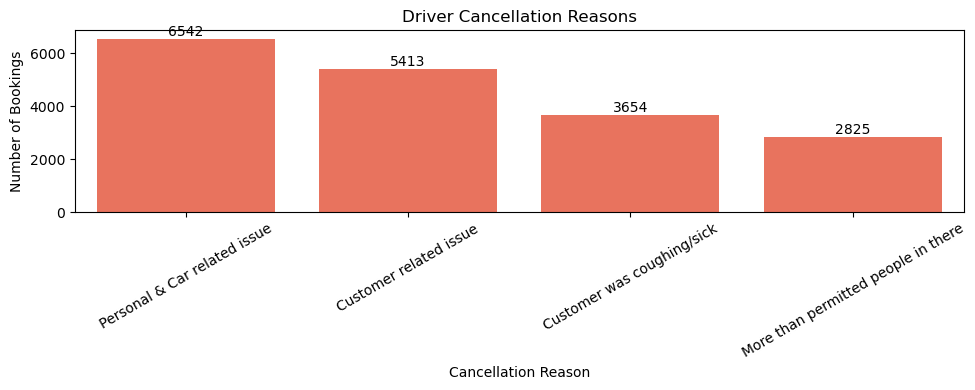

In [55]:
plt.figure(figsize=(10,4))
ax = sns.barplot(
    data=driver_cancel,
    x="Canceled_Rides_by_Driver",
    y="Booking_ID",
    color="tomato"
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30)
plt.title("Driver Cancellation Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

In [56]:
#Which vehicle type has the highest customer cancellations?
vehicle_cancel_customer= (df[df["Canceled_Rides_by_Customer"]!='No Cancellation'].groupby('Vehicle_Type')["Canceled_Rides_by_Customer"]
                  .count().sort_values(ascending=False)
                  .reset_index(0))
vehicle_cancel_customer

,Vehicle_Type,Canceled_Rides_by_Customer
0,Bike,1537
1,eBike,1512
2,Mini,1505
3,Auto,1503
4,Prime SUV,1498
5,Prime Plus,1474
6,Prime Sedan,1470


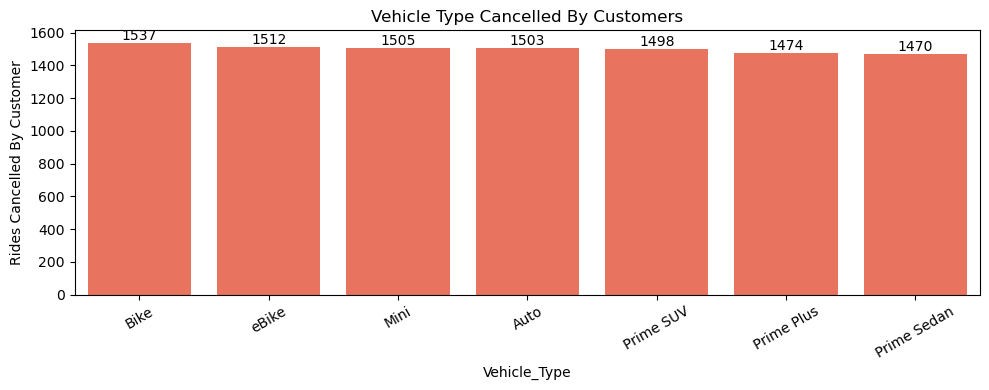

In [57]:
plt.figure(figsize=(10,4))
ax = sns.barplot(
    data=vehicle_cancel_customer,
    x="Vehicle_Type",
    y="Canceled_Rides_by_Customer",
    color="tomato"
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30)
plt.title("Vehicle Type Cancelled By Customers")
plt.xlabel("Vehicle_Type")
plt.ylabel("Rides Cancelled By Customer")
plt.tight_layout()
plt.show()

In [58]:
#Cancellation Percentage by Vehicle Type
total_booking= df.groupby("Vehicle_Type")["Booking_ID"].count().sort_values(ascending=False).reset_index(0)
total_booking.columns=['Vehicle_Type','Total_Bookings']
total_booking


,Vehicle_Type,Total_Bookings
0,Prime Sedan,14877
1,eBike,14816
2,Auto,14755
3,Prime Plus,14707
4,Bike,14662
5,Prime SUV,14655
6,Mini,14552


In [59]:
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Hour,Day,Month,Weekday,Pick_Drop_Location
0,2024-07-26 14:00:00,1900-01-01 14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,0.0,0.0,...,Not Applicable,0,0.0,0.0,#NAME?,14,Friday,July,4,Tumkur Road-RT Nagar
1,2024-07-25 22:20:00,1900-01-01 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,Cash,13,4.1,4.0,#NAME?,22,Thursday,July,3,Magadi Road-Varthur
2,2024-07-30 19:59:00,1900-01-01 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,UPI,40,4.2,4.8,#NAME?,19,Tuesday,July,1,Sahakar Nagar-Varthur
3,2024-07-22 03:15:00,1900-01-01 03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,0.0,0.0,...,Not Applicable,0,0.0,0.0,#NAME?,3,Monday,July,0,HSR Layout-Vijayanagar
4,2024-07-02 09:02:00,1900-01-01 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,Credit Card,45,4.0,3.0,#NAME?,9,Tuesday,July,1,Rajajinagar-Chamarajpet


In [60]:
cancelled_bookings=(df[df["Booking_Status"]!='Success'].groupby('Vehicle_Type')["Booking_Status"]
                  .count().sort_values(ascending=False)
                  .reset_index(0))
cancelled_bookings.columns=['Vehicle_Type','Cancelled_Booking']
cancelled_bookings

,Vehicle_Type,Cancelled_Booking
0,Prime SUV,5659
1,eBike,5636
2,Prime Plus,5632
3,Auto,5588
4,Bike,5528
5,Mini,5516
6,Prime Sedan,5498


In [61]:
cancel_percentage = pd.merge(
    total_booking,
    cancelled_bookings,
    on="Vehicle_Type"
)
cancel_percentage

,Vehicle_Type,Total_Bookings,Cancelled_Booking
0,Prime Sedan,14877,5498
1,eBike,14816,5636
2,Auto,14755,5588
3,Prime Plus,14707,5632
4,Bike,14662,5528
5,Prime SUV,14655,5659
6,Mini,14552,5516


In [62]:
cancel_percentage["Cancellation%"]=(
    cancel_percentage["Cancelled_Booking"]/cancel_percentage["Total_Bookings"]
)*100
cancel_percentage

,Vehicle_Type,Total_Bookings,Cancelled_Booking,Cancellation%
0,Prime Sedan,14877,5498,36.956376
1,eBike,14816,5636,38.039957
2,Auto,14755,5588,37.871908
3,Prime Plus,14707,5632,38.294690
4,Bike,14662,5528,37.702905
5,Prime SUV,14655,5659,38.614807
6,Mini,14552,5516,37.905443


In [63]:
cancel_percentage=cancel_percentage.sort_values("Cancellation%",ascending=False)
cancel_percentage

,Vehicle_Type,Total_Bookings,Cancelled_Booking,Cancellation%
5,Prime SUV,14655,5659,38.614807
3,Prime Plus,14707,5632,38.294690
1,eBike,14816,5636,38.039957
6,Mini,14552,5516,37.905443
2,Auto,14755,5588,37.871908
4,Bike,14662,5528,37.702905
0,Prime Sedan,14877,5498,36.956376


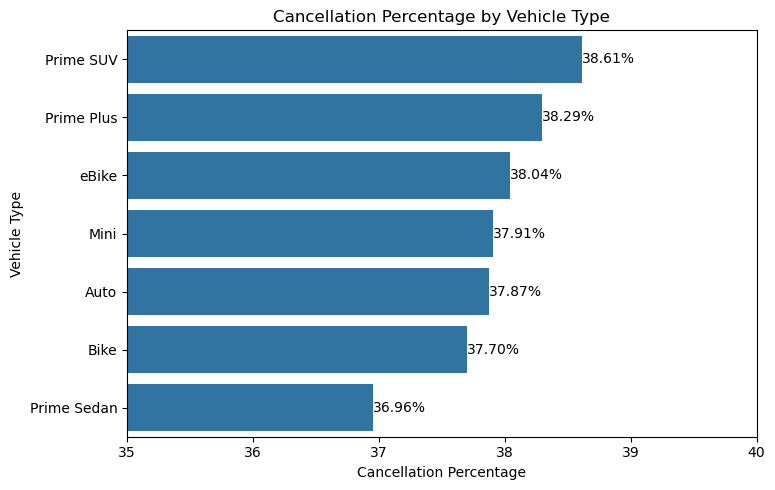

In [64]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=cancel_percentage,
    y="Vehicle_Type",
    x="Cancellation%"
)
ax.bar_label(ax.containers[0], fmt="%.2f%%")
plt.title("Cancellation Percentage by Vehicle Type")
plt.xlabel("Cancellation Percentage")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.xlim(35, 40)
plt.show()

In [65]:
#Bookings by Hour
hourly_bookings=df.groupby("Hour")["Booking_ID"].count().reset_index(0)
hourly_bookings.columns=["Hour","Booking Count"]
hourly_bookings

,Hour,Booking Count
0,0,4318
1,1,4329
2,2,4305
3,3,4201
4,4,4263
5,5,4264
6,6,4271
7,7,4304
8,8,4374
9,9,4347


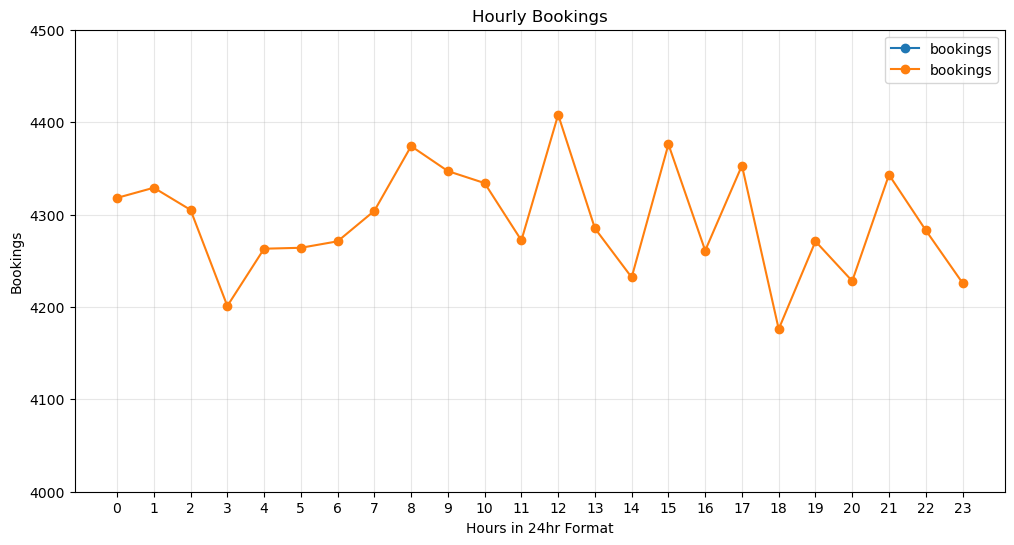

In [81]:
plt.figure(figsize=(12,6))
plt.plot(hourly_bookings,label="bookings",marker='o')
plt.title("Hourly Bookings")
plt.xlabel("Hours in 24hr Format")
plt.ylabel("Bookings")
plt.ylim(4000,4500)
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [67]:
#Bookings by Day of Week
booking_dayofweek= df.groupby("Day")["Booking_ID"].count().reset_index(0)
booking_dayofweek

,Day,Booking_ID
0,Friday,13345
1,Monday,16729
2,Saturday,13341
3,Sunday,13013
4,Thursday,13236
5,Tuesday,16926
6,Wednesday,16434


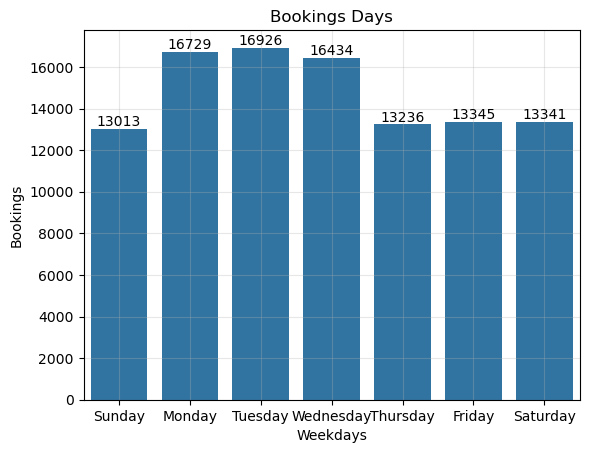

In [68]:
ax=sns.barplot(booking_dayofweek,x="Day",y="Booking_ID"
               ,order=["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"])
ax.bar_label(ax.containers[0])
plt.title("Bookings Days")
plt.xlabel("Weekdays")
plt.ylabel("Bookings")
plt.grid(alpha=0.3)
plt.show()

In [69]:
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Hour', 'Day', 'Month', 'Weekday',
       'Pick_Drop_Location'],
      dtype='object')

In [72]:
#Which hour generates the highest revenue?
hourly_revenue=df.groupby('Hour')['Booking_Value'].sum().reset_index(0)
hourly_revenue

,Hour,Booking_Value
0,0,2399829
1,1,2416576
2,2,2368167
3,3,2332716
4,4,2348305
5,5,2321733
6,6,2387209
7,7,2444489
8,8,2334830
9,9,2359404


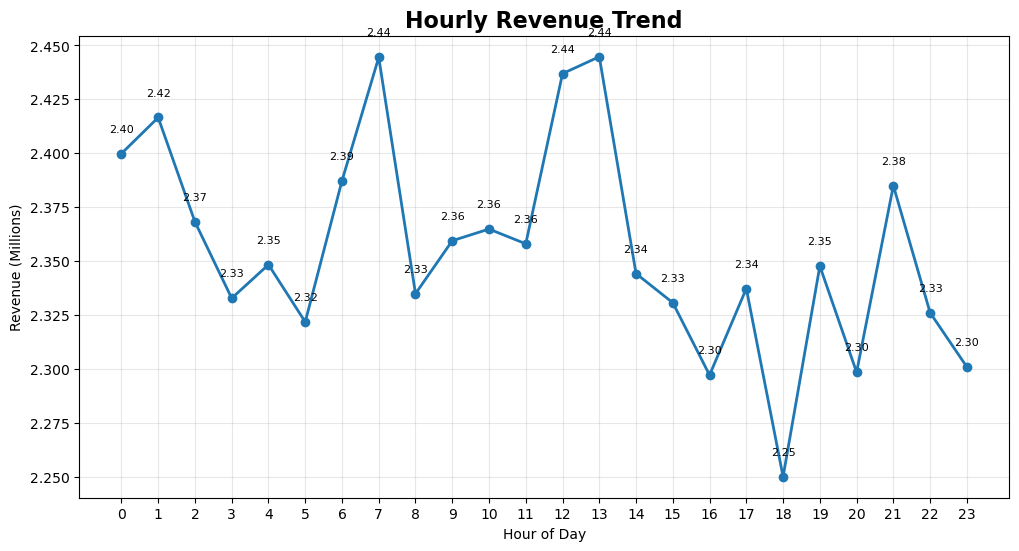

In [79]:
plt.figure(figsize=(12,6))

plt.plot(
    hourly_revenue["Hour"],
    hourly_revenue["Booking_Value"]/1e6,
    marker='o',
    linewidth=2
)

for x, y in zip(hourly_revenue["Hour"], hourly_revenue["Booking_Value"]/1e6):
    plt.text(x, y+0.01, f"{y:.2f}", ha='center', fontsize=8)

plt.title("Hourly Revenue Trend", fontsize=16, weight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (Millions)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Saving Cleaned Dataset to CSV for power bi dashboard
df.to_csv("Ola_Cleaned.csv", index=False)

📊 Key Business Insights

Example:

Business Insights
Successfully completed rides account for the majority of bookings, indicating healthy operational performance.

Prime SUV records the highest cancellation percentage (38.61%), while Prime Sedan has the lowest (36.96%). However, the variation across vehicle types is minimal, suggesting cancellations are influenced more by operational factors than vehicle type.

Digital payment methods dominate successful bookings, highlighting strong customer adoption of cashless payments.

Certain pickup locations consistently generate higher booking volumes, making them ideal candidates for driver allocation during peak hours.

Revenue remains relatively consistent throughout the day with slight variations across different hours.

Average customer and driver ratings remain above acceptable levels, indicating satisfactory service quality.

Ride distances span from short urban trips to longer journeys, showing that customers use the platform for diverse travel needs.

Customer cancellations primarily occur due to reasons such as driver delays or booking changes, indicating opportunities to improve dispatch efficiency.

Conclusion

This exploratory data analysis transformed raw ride-booking data into actionable business insights. Through data cleaning, feature engineering, statistical analysis, and visualization, several operational patterns regarding bookings, revenue, customer behavior, cancellations, vehicle performance, and ride trends were identified.

These insights can help stakeholders improve fleet allocation, reduce cancellations, optimize pricing strategies, and enhance the overall customer experience. The cleaned dataset and findings will also serve as the foundation for the accompanying Power BI dashboard.